# Estudio Demography Data

## Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found

In [2]:
# Cargar el dataset
path = 'data/merged_sets/demographic_data.csv'
df_exam = pd.read_csv(path)

# Descartar el identificador SEQN
if 'SEQN' in df_exam.columns:
    df_exam = df_exam.drop(columns=['SEQN'])
    print("Columna 'SEQN' eliminada correctamente.")

# 1. Qué tipo de variables tenemos
print("--- Estructura del Dataset ---")
print(df_exam.info())

print("\n--- Conteo de tipos de datos ---")
print(df_exam.dtypes.value_counts())

# Separación sugerida para análisis
numeric_cols = df_exam.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_exam.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nVariables Numéricas ({len(numeric_cols)}): {numeric_cols[:5]}...") # Mostramos solo las primeras 5
print(f"Variables Categóricas ({len(categorical_cols)}): {categorical_cols}")

Columna 'SEQN' eliminada correctamente.
--- Estructura del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SDDSRVYR  11933 non-null  float64
 1   RIDSTATR  11933 non-null  float64
 2   RIAGENDR  11933 non-null  float64
 3   RIDAGEYR  11933 non-null  float64
 4   RIDRETH1  11933 non-null  float64
 5   RIDRETH3  11933 non-null  float64
 6   RIDEXMON  8860 non-null   float64
 7   DMDBORN4  11914 non-null  float64
 8   DMDHHSIZ  11933 non-null  float64
 9   WTINT2YR  11933 non-null  float64
 10  WTMEC2YR  11933 non-null  float64
 11  SDMVSTRA  11933 non-null  float64
 12  SDMVPSU   11933 non-null  float64
 13  INDFMPIR  9892 non-null   float64
dtypes: float64(14)
memory usage: 1.3 MB
None

--- Conteo de tipos de datos ---
float64    14
Name: count, dtype: int64

Variables Numéricas (14): ['SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1']

--- Columnas con valores faltantes ---
          Nulos  Porcentaje (%)
RIDEXMON   3073       25.752116
INDFMPIR   2041       17.103830
DMDBORN4     19        0.159222


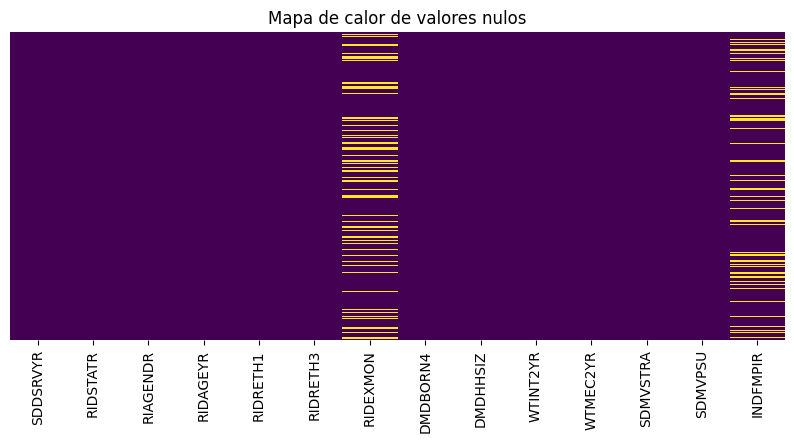

In [3]:
# 2. Análisis de nulos
null_count = df_exam.isnull().sum()
null_percentage = (null_count / len(df_exam)) * 100

null_df = pd.DataFrame({
    'Nulos': null_count,
    'Porcentaje (%)': null_percentage
}).sort_values(by='Nulos', ascending=False)

# Mostrar solo las columnas que tienen nulos
print("--- Columnas con valores faltantes ---")
print(null_df[null_df['Nulos'] > 0])

# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_exam.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

--- Resumen de Outliers en el Dataset ---


,Columna,Outliers,Porcentaje (%)
5,RIDRETH3,2746,23.01
7,DMDBORN4,1875,15.71
4,RIDRETH1,1117,9.36
9,WTINT2YR,679,5.69
10,WTMEC2YR,377,3.16
1,RIDSTATR,0,0.00
2,RIAGENDR,0,0.00
3,RIDAGEYR,0,0.00
0,SDDSRVYR,0,0.00
6,RIDEXMON,0,0.00


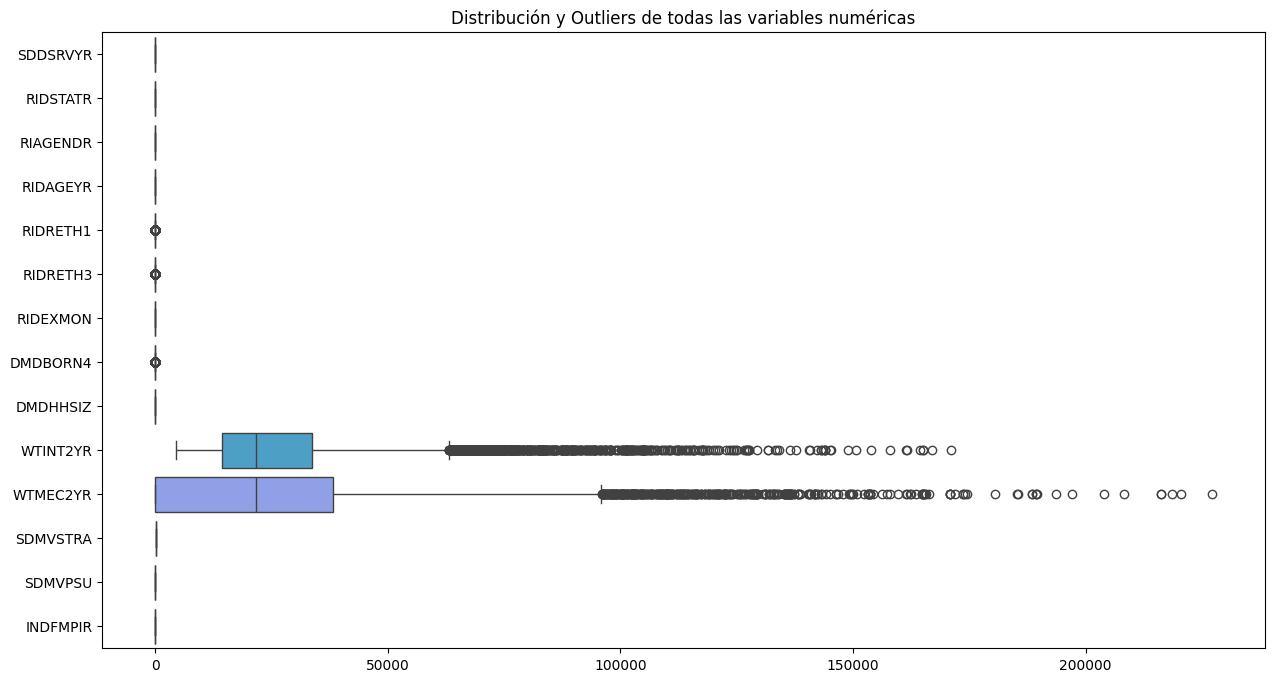

In [4]:
# 2. Análisis de Outliers
outliers_summary = []

for col in numeric_cols:
    Q1 = df_exam[col].quantile(0.25)
    Q3 = df_exam[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Contar cuántos valores están fuera de los límites
    num_outliers = df_exam[(df_exam[col] < lower_bound) | (df_exam[col] > upper_bound)].shape[0]
    perc_outliers = (num_outliers / len(df_exam)) * 100
    
    outliers_summary.append({
        'Columna': col,
        'Outliers': num_outliers,
        'Porcentaje (%)': round(perc_outliers, 2)
    })

# Convertir a DataFrame para visualizar mejor
df_outliers = pd.DataFrame(outliers_summary).sort_values(by='Outliers', ascending=False)
print("--- Resumen de Outliers en el Dataset ---")
display(df_outliers)

# Visualización general (Boxplot de todas las variables normalizadas para comparar)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_exam[numeric_cols], orient="h")
plt.title("Distribución y Outliers de todas las variables numéricas")
plt.show()

--- Estadísticos Principales ---


,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDHHSIZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
count,11933.0,11933.000000,11933.000000,1.193300e+04,11933.000000,11933.000000,8860.000000,11914.000000,11933.000000,11933.000000,1.193300e+04,11933.000000,11933.000000,9.892000e+03
mean,12.0,1.742479,1.532808,3.831786e+01,3.104584,3.320540,1.520203,1.157378,3.242772,27404.135674,2.740414e+04,179.918294,1.491746,2.708174e+00
std,0.0,0.437287,0.498943,2.560199e+01,1.076346,1.518379,0.499620,0.364172,1.699512,19449.155209,2.796296e+04,4.309624,0.499953,1.670119e+00
min,12.0,1.000000,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000,1.000000,4584.463196,5.397605e-79,173.000000,1.000000,5.397605e-79
25%,12.0,1.000000,1.000000,1.300000e+01,3.000000,3.000000,1.000000,1.000000,2.000000,14331.753594,5.397605e-79,176.000000,1.000000,1.180000e+00
50%,12.0,2.000000,2.000000,3.700000e+01,3.000000,3.000000,2.000000,1.000000,3.000000,21670.185970,2.171785e+04,180.000000,1.000000,2.500000e+00
75%,12.0,2.000000,2.000000,6.200000e+01,4.000000,4.000000,2.000000,1.000000,4.000000,33831.331556,3.834115e+04,184.000000,2.000000,4.500000e+00
max,12.0,2.000000,2.000000,8.000000e+01,5.000000,7.000000,2.000000,2.000000,7.000000,170968.343177,2.271083e+05,187.000000,2.000000,5.000000e+00


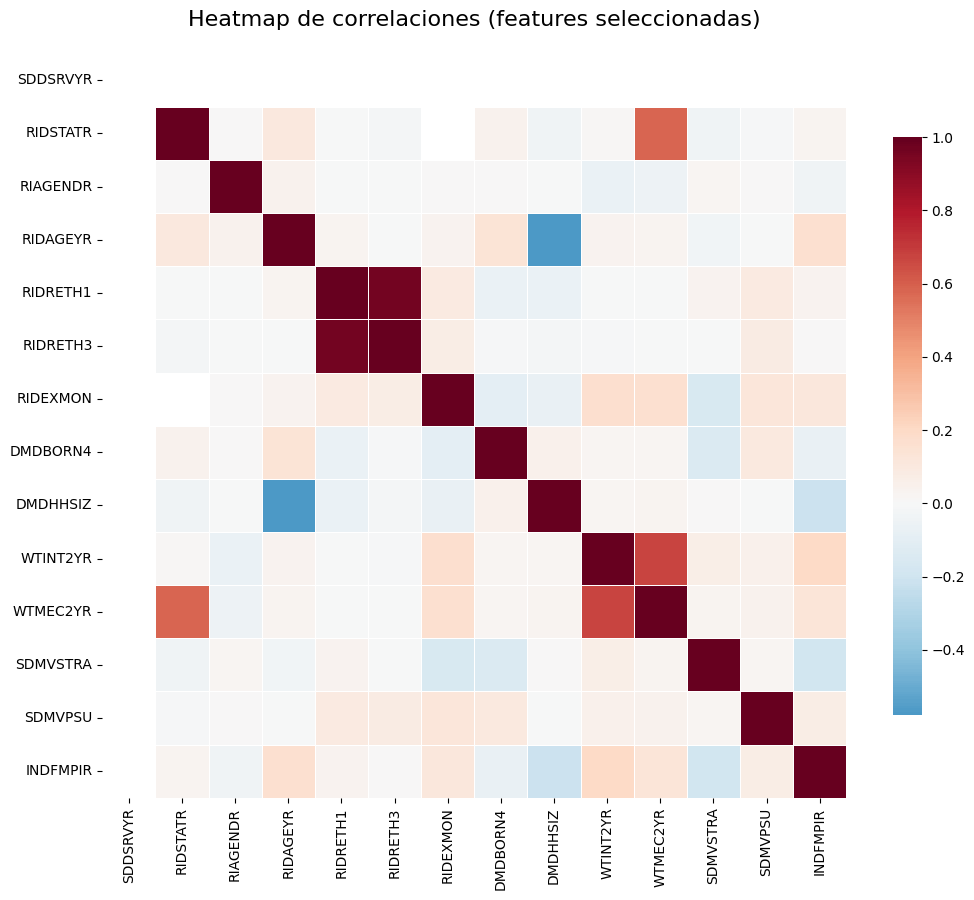


--- Parejas de variables con mayor correlación positiva ---


RIDRETH1  RIDRETH3    0.959359
WTINT2YR  WTMEC2YR    0.672413
RIDSTATR  WTMEC2YR    0.577186
WTINT2YR  INDFMPIR    0.199212
RIDEXMON  WTINT2YR    0.166089
dtype: float64


--- Parejas de variables con mayor correlación negativa ---


INDFMPIR  WTINT2YR   NaN
          WTMEC2YR   NaN
          SDMVSTRA   NaN
          SDMVPSU    NaN
          INDFMPIR   NaN
dtype: float64

In [6]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df_exam.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df_exam[numeric_cols].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Ranking de correlaciones (para no perder el dato exacto del Top 5)
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("\n--- Parejas de variables con mayor correlación positiva ---")
display(sol.head(5))

print("\n--- Parejas de variables con mayor correlación negativa ---")
display(sol.tail(5))